In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import random
import os

# Установка всех сидов для полной воспроизводимости
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Для детерминистичности на GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
df = pd.read_csv('../data/CreditPrediction.csv')

In [4]:
df.head(10)

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Unnamed: 19
0,768805383,45.0,M,3,High School,Married,$60K - $80K,Blue,39.0,5.0,1,3,12691.0,777,1.335,1144,42,1.625,0.061,NaN
1,818770008,49.0,F,5,Graduate,NaN,Less than $40K,Blue,44.0,6.0,1,2,8256.0,864,1.541,1291,33,3.714,0.105,NaN
2,713982108,51.0,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4.0,1,0,3418.0,0,2.594,1887,20,2.333,0.000,NaN
3,769911858,40.0,F,4,High School,NaN,Less than $40K,Blue,34.0,3.0,4,1,3313.0,2517,1.405,1171,20,2.333,0.760,NaN
4,709106358,40.0,M,3,Uneducated,Married,$60K - $80K,NaN,21.0,5.0,1,0,4716.0,0,2.175,816,28,2.500,0.000,NaN
5,713061558,44.0,M,2,Graduate,Married,$40K - $60K,Blue,36.0,3.0,1,2,4010.0,1247,1.376,1088,24,0.846,0.311,NaN
6,810347208,51.0,M,4,Unknown,Married,$120K +,Gold,46.0,6.0,1,3,34516.0,2264,1.975,1330,31,0.722,0.066,NaN
7,818906208,32.0,M,0,High School,Unknown,$60K - $80K,Silver,27.0,2.0,2,2,29081.0,1396,2.204,1538,36,0.714,0.048,NaN
8,710930508,37.0,M,3,Uneducated,Single,$60K - $80K,NaN,36.0,5.0,2,0,22352.0,2517,3.355,1350,24,1.182,0.113,NaN
9,719661558,48.0,M,2,Graduate,Single,$80K - $120K,Blue,36.0,6.0,3,3,11656.0,1677,1.524,1441,32,0.882,0.144,NaN


In [5]:
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])

In [6]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10167.000000,10167.000000,9944.000000,10147.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000,10167.000000
mean,46.753817,2.346513,35.913415,3.813245,2.341595,2.455887,8632.552346,1162.176748,0.759721,4402.349661,64.864463,0.712192,0.274716
std,13.520505,1.298701,7.980102,1.554741,1.010502,1.105580,9087.333842,815.082643,0.219054,3393.953441,23.461680,0.237934,0.275638
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2556.500000,348.500000,0.631000,2155.500000,45.000000,0.582000,0.022000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,0.736000,3900.000000,67.000000,0.702000,0.175000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1783.000000,0.859000,4740.000000,81.000000,0.818000,0.502500
max,352.330517,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10167 entries, 0 to 10166
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10167 non-null  float64
 1   Gender                    9968 non-null   object 
 2   Dependent_count           10167 non-null  int64  
 3   Education_Level           10167 non-null  object 
 4   Marital_Status            8217 non-null   object 
 5   Income_Category           10167 non-null  object 
 6   Card_Category             8243 non-null   object 
 7   Months_on_book            9944 non-null   float64
 8   Total_Relationship_Count  10147 non-null  float64
 9   Months_Inactive_12_mon    10167 non-null  int64  
 10  Contacts_Count_12_mon     10167 non-null  int64  
 11  Credit_Limit              10167 non-null  float64
 12  Total_Revolving_Bal       10167 non-null  int64  
 13  Total_Amt_Chng_Q4_Q1      10167 non-null  float64
 14  Total_

In [8]:
df = df[(df['Total_Amt_Chng_Q4_Q1'] <= 2.8) & (df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10148


In [9]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [10]:
print(f'Уникальные значения для категориальных колонок:')

for col_name in cat_cols:
    print(f'{col_name} - {df[col_name].unique()}', end='\n\n')

Уникальные значения для категориальных колонок:
Gender - ['M' 'F' nan]

Education_Level - ['High School' 'Graduate' 'Uneducated' 'Unknown' 'Post-Graduate'
 'Doctorate' 'College']

Marital_Status - ['Married' nan 'Unknown' 'Single' 'Divorced']

Income_Category - ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Card_Category - ['Blue' nan 'Gold' 'Silver' 'Platinum']



In [11]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')

In [12]:
for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

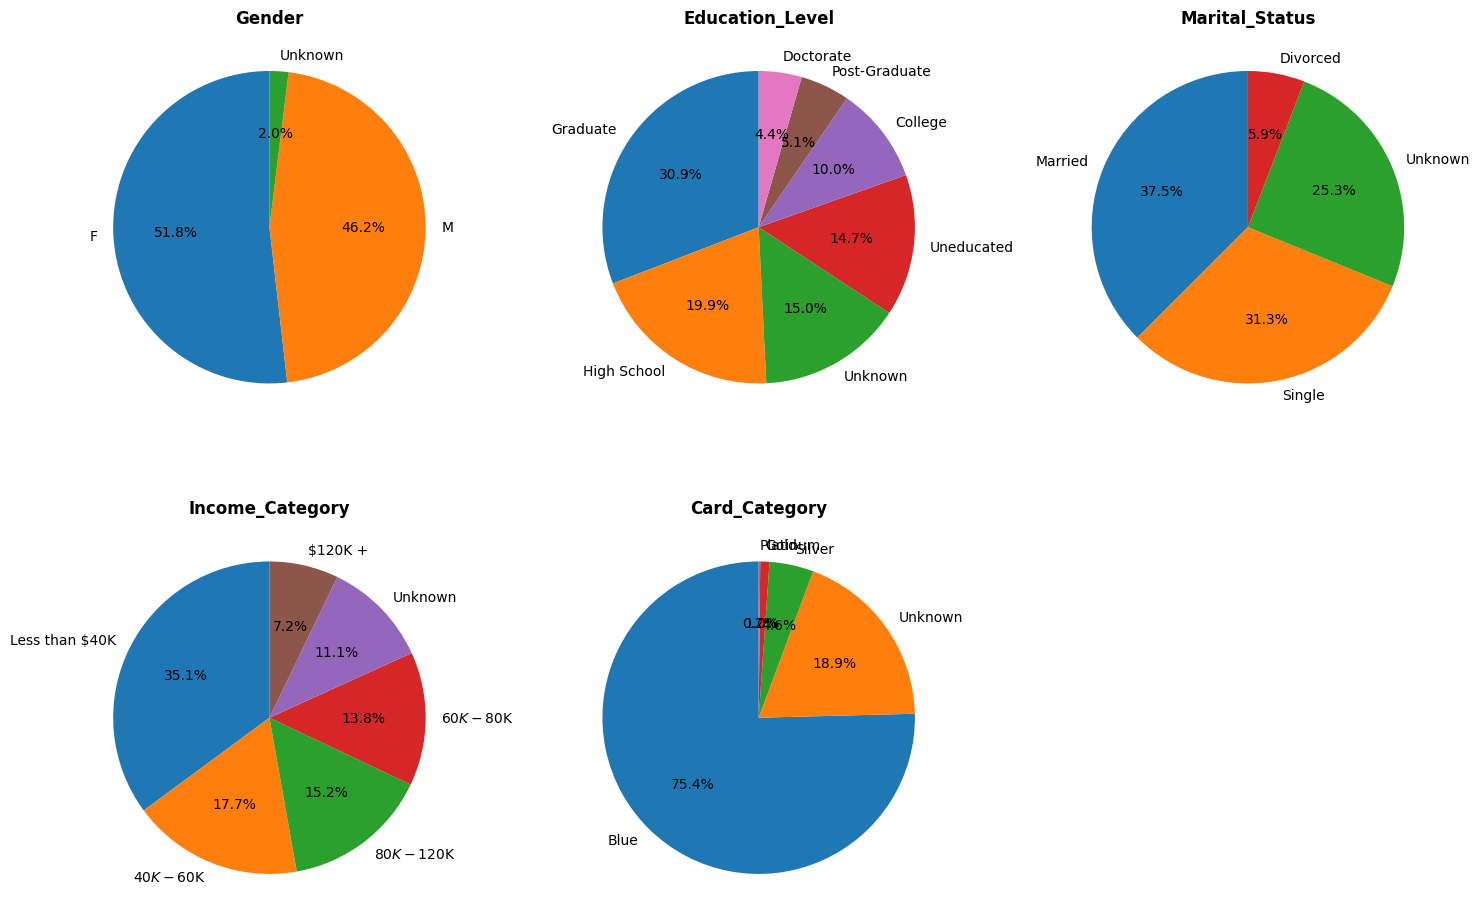

In [13]:
# Диаграммы пирогов для категориальных признаков
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for idx, col_name in enumerate(cat_cols):
    value_counts = df[col_name].value_counts()
    axes[idx].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    axes[idx].set_title(col_name, fontsize=12, fontweight='bold')

# Удаляем пустые оси если колонок меньше чем ячеек в сетке
for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [14]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6088 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


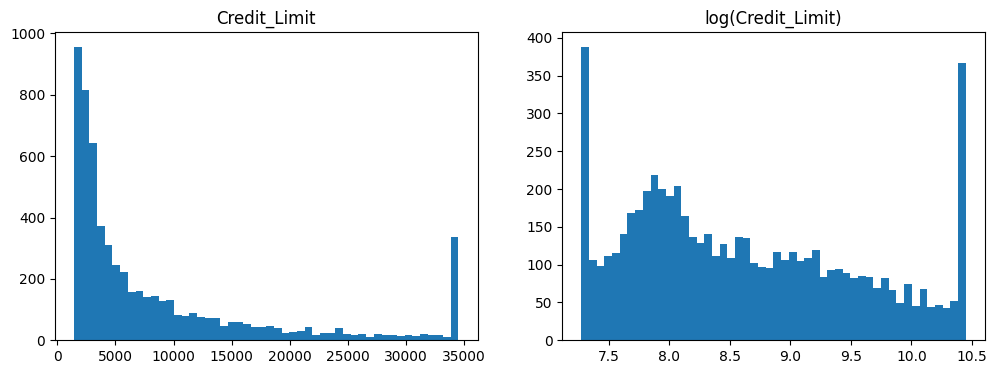

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
y_train_log = np.log(y_train.values)
axes[0].hist(y_train, bins=50); axes[0].set_title('Credit_Limit')
axes[1].hist(y_train_log, bins=50); axes[1].set_title('log(Credit_Limit)')
plt.show()

In [16]:
import joblib
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=cat_cols, smoothing=10.0, handle_unknown='value')

# Отдельно логарифмируем таргет
y_train_log = np.log(y_train.values)
y_val_log   = np.log(y_val.values)
y_test_log  = np.log(y_test.values)

# y_train_log = y_train.values
# y_val_log = y_val.values
# y_test_log = y_test.values

X_train_enc = encoder.fit_transform(X_train, y_train_log)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

joblib.dump(encoder, "../artifacts/target_encoder_nn_base_log.pkl")

['../artifacts/target_encoder_nn_base_log.pkl']

In [17]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = X_train_enc.copy()
X_train_scaled = scaler.fit_transform(X_train_enc)

X_val_scaled = X_val_enc.copy()
X_val_scaled = scaler.transform(X_val_enc)

X_test_scaled = X_test_enc.copy()
X_test_scaled = scaler.transform(X_test_enc)

In [18]:
X_train_scaled.shape

(6088, 17)

In [19]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_log).reshape(-1, 1)

X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val_log).reshape(-1, 1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_log).reshape(-1, 1)

In [20]:
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [20]:
model = nn.Sequential(
    nn.Linear(17, 64),
    # nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 64),
    # nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=1e-3)

In [21]:
def plot_training_progress(train_losses, val_losses, epoch, num_epochs, best_val_loss):
    """Рисует график прогресса обучения"""
    clear_output(wait=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(train_losses, c='m', linewidth=2, label='Train Loss')
    ax.plot(val_losses, c='y', linewidth=2, label='Val Loss')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Training Progress - Epoch {epoch}/{num_epochs}', fontsize=14, fontweight='bold')
    
    # Добавляем текст с текущими значениями
    textstr = f'Train Loss (current): {train_losses[-1]:.4f} (best: {min(train_losses):.4f})\n'
    textstr += f'Val Loss (current): {val_losses[-1]:.4f} (best: {best_val_loss:.4f})'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

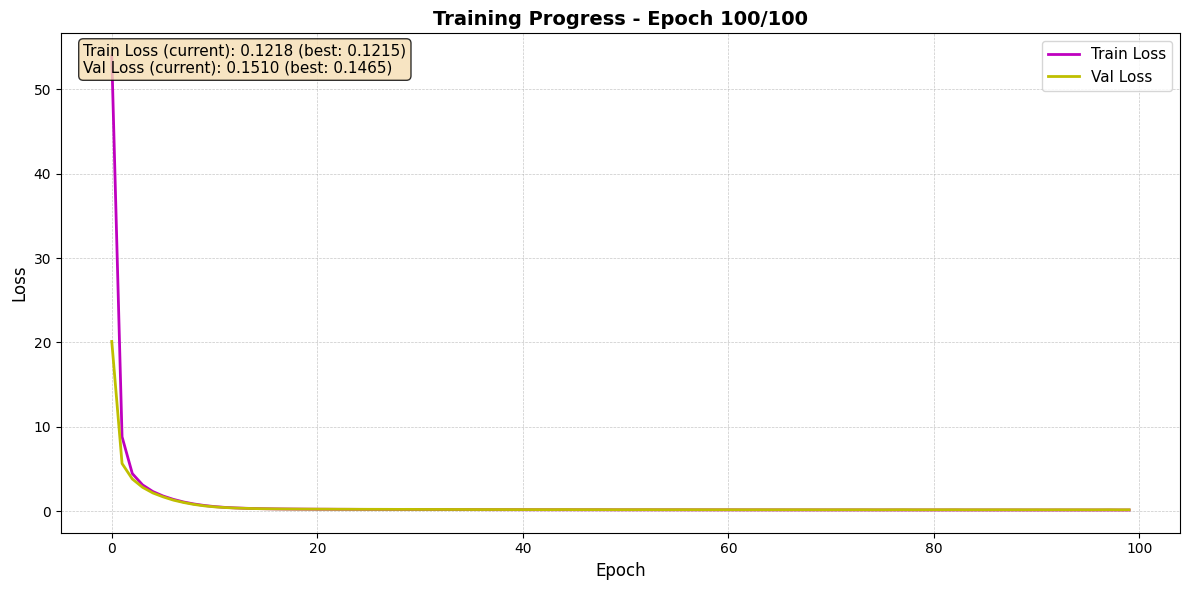

Лучший лосс на train: 0.1215, на val: 0.1465
Loaded best model with Val Loss: 0.1465


In [ ]:
NUM_EPOCHS = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.shape[0]
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_dataloader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            
            pred = model(x_batch)
            loss = criterion(pred, y_batch)

            val_loss += loss.item() * x_batch.shape[0]

    val_loss /= len(val_dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss 
        best_model_state = model.state_dict().copy()

    if epoch % 10 == 0:
        plot_training_progress(train_losses, val_losses, epoch, NUM_EPOCHS, best_val_loss)

plot_training_progress(train_losses, val_losses, NUM_EPOCHS, NUM_EPOCHS, best_val_loss)

print(f'Лучший лосс на train: {min(train_losses):.4f}, на val: {best_val_loss:.4f}')

if best_model_state is not None:
    torch.save(best_model_state, '../artifacts/model_nn_base.pth')
    # model.load_state_dict(torch.load('artifacts/model_best.pth'))
    model.load_state_dict(best_model_state)
    print(f"Loaded best model with Val Loss: {best_val_loss:.4f}")



In [ ]:
# Вычисление метрик нейросетевой модели на всех наборах
model.eval()
with torch.no_grad():
    # Train метрики
    X_train_device = X_train_tensor.to(device)
    y_train_device = y_train_tensor.to(device)
    y_train_pred_nn = np.exp(model(X_train_device).cpu().numpy())
    y_train_actual = np.exp(y_train_device.cpu().numpy())
    
    # Val метрики
    X_val_device = X_val_tensor.to(device)
    y_val_device = y_val_tensor.to(device)
    y_val_pred_nn = np.exp(model(X_val_device).cpu().numpy())
    y_val_actual = np.exp(y_val_device.cpu().numpy())
    
    # Test метрики
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)
    y_test_pred_nn = np.exp(model(X_test_device).cpu().numpy())
    y_test_actual = np.exp(y_test_device.cpu().numpy())

def calculate_nn_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R²:   {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики Neural Network модели')
print('=' * 50)

train_nn_metrics = calculate_nn_metrics(y_train_actual, y_train_pred_nn, 'TRAIN')
val_nn_metrics = calculate_nn_metrics(y_val_actual, y_val_pred_nn, 'VALIDATION')
test_nn_metrics = calculate_nn_metrics(y_test_actual, y_test_pred_nn, 'TEST')

print('\n' + '=' * 50)

Метрики Neural Network модели

TRAIN:
  MSE:  13836837.0000
  RMSE: 3719.7899
  MAE:  1785.4512
  R²:   0.8361

VALIDATION:
  MSE:  16609835.0000
  RMSE: 4075.5165
  MAE:  1931.6276
  R²:   0.7879

TEST:
  MSE:  14689946.0000
  RMSE: 3832.7465
  MAE:  1858.8417
  R²:   0.8186



In [22]:
model1 = nn.Sequential(
    nn.Linear(17, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

In [25]:
criterion = nn.MSELoss()
optimizer = Adam(model1.parameters(), lr=1e-3)

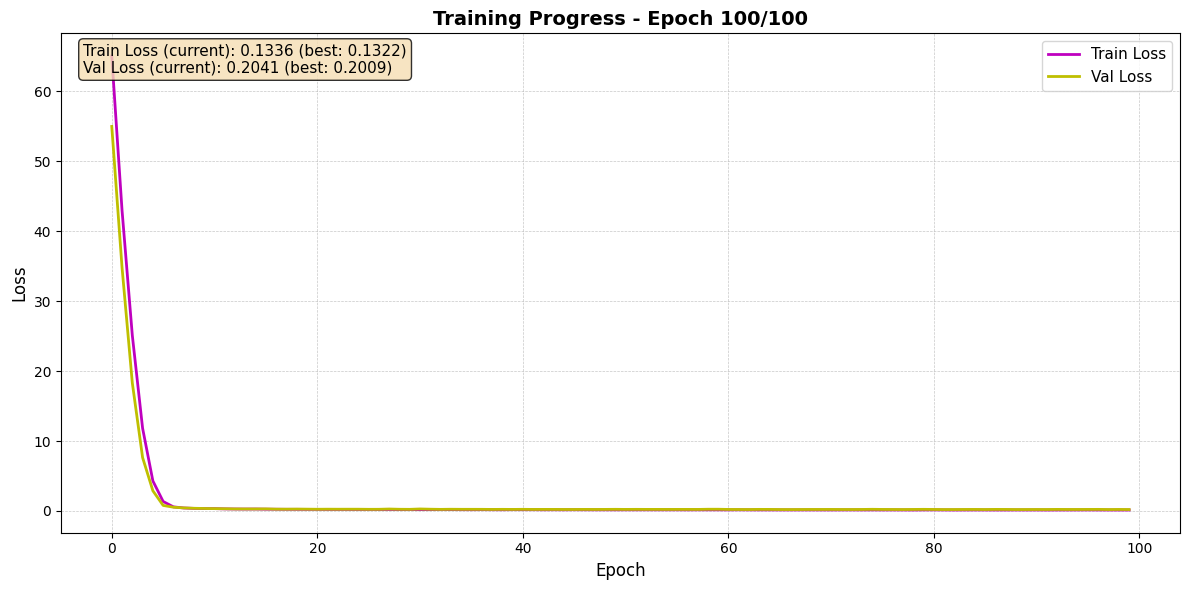

Лучший лосс на train: 0.1322, на val: 0.2009
Loaded best model with Val Loss: 0.2009


In [ ]:
NUM_EPOCHS = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(NUM_EPOCHS):
    model1.train()
    train_loss = 0
    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model1(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.shape[0]
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model1.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_dataloader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            
            pred = model1(x_batch)
            loss = criterion(pred, y_batch)

            val_loss += loss.item() * x_batch.shape[0]

    val_loss /= len(val_dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss 
        best_model_state = model1.state_dict().copy()

    if epoch % 10 == 0:
        plot_training_progress(train_losses, val_losses, epoch, NUM_EPOCHS, best_val_loss)

plot_training_progress(train_losses, val_losses, NUM_EPOCHS, NUM_EPOCHS, best_val_loss)

print(f'Лучший лосс на train: {min(train_losses):.4f}, на val: {best_val_loss:.4f}')

if best_model_state is not None:
    torch.save(best_model_state, '../artifacts/model_nn_bn_base.pth')
    # model.load_state_dict(torch.load('artifacts/model_best.pth'))
    model1.load_state_dict(best_model_state)
    print(f"Loaded best model with Val Loss: {best_val_loss:.4f}")



In [27]:
# Вычисление метрик нейросетевой модели на всех наборах
model1.eval()
with torch.no_grad():
    # Train метрики
    X_train_device = X_train_tensor.to(device)
    y_train_device = y_train_tensor.to(device)
    y_train_pred_nn = np.exp(model1(X_train_device).cpu().numpy())
    y_train_actual = np.exp(y_train_device.cpu().numpy())
    
    # Val метрики
    X_val_device = X_val_tensor.to(device)
    y_val_device = y_val_tensor.to(device)
    y_val_pred_nn = np.exp(model1(X_val_device).cpu().numpy())
    y_val_actual = np.exp(y_val_device.cpu().numpy())
    
    # Test метрики
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)
    y_test_pred_nn = np.exp(model1(X_test_device).cpu().numpy())
    y_test_actual = np.exp(y_test_device.cpu().numpy())

def calculate_nn_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R²:   {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики Neural Network модели')
print('=' * 50)

train_nn_metrics = calculate_nn_metrics(y_train_actual, y_train_pred_nn, 'TRAIN')
val_nn_metrics = calculate_nn_metrics(y_val_actual, y_val_pred_nn, 'VALIDATION')
test_nn_metrics = calculate_nn_metrics(y_test_actual, y_test_pred_nn, 'TEST')

print('\n' + '=' * 50)

Метрики Neural Network модели

TRAIN:
  MSE:  13029488.0000
  RMSE: 3609.6382
  MAE:  1911.6327
  R²:   0.8457

VALIDATION:
  MSE:  24707738.0000
  RMSE: 4970.6879
  MAE:  2654.1045
  R²:   0.6845

TEST:
  MSE:  22051036.0000
  RMSE: 4695.8531
  MAE:  2597.5847
  R²:   0.7276

